In [1]:
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os
import requests
from dotenv import load_dotenv
import io
import time

In [25]:
load_dotenv()  # take environment variables from .env file
TIINGO_API = os.getenv("tiingo_api_key")

# Dedicated headers for Tiingo (uses Authorization header)
headers = {
    'Authorization': f'Token {TIINGO_API}'
}
today = time.strftime("%Y-%m-%d")

START = '2020-01-01'

In [27]:
params = {
    'startDate': START,
    'endDate': today,
    'format': 'csv',
    'resampleFreq': '1day'
}
ccy = 'usdchf'

resp_fx = requests.get(f'https://api.tiingo.com/tiingo/fx/{ccy}/prices',params=params,headers=headers)


# resp_fx = requests.get(f'https://api.tiingo.com/tiingo/fx/{ccy}/prices?token={TIINGO_API}&startDate=2024-1-1&endDate={today}&format=csv&resampleFreq=1day')
resp_fx.raise_for_status()
fxdata = resp_fx.content

In [28]:
df = pd.read_csv(io.BytesIO(fxdata),header=0, skiprows=[1], parse_dates=[0], index_col=0).sort_index()
# adj = df['adjClose']
# close=df['close']
print(list(df.columns))
df.index.dtype

['ticker', 'close', 'high', 'low', 'open']


datetime64[ns, UTC]

In [171]:
df = pd.read_csv(io.BytesIO(data),header=0, skiprows=[1], parse_dates=[0], index_col=0).sort_index()
# adj = df['adjClose']
# close=df['close']
print(list(df.columns))
df.index.dtype


[]


dtype('O')

date
2024-01-01 00:00:00+00:00    0.842025
2024-01-02 00:00:00+00:00    0.850115
2024-01-03 00:00:00+00:00    0.849245
2024-01-04 00:00:00+00:00    0.850280
2024-01-05 00:00:00+00:00    0.850305
                               ...   
2025-08-25 00:00:00+00:00    0.806270
2025-08-26 00:00:00+00:00    0.803850
2025-08-27 00:00:00+00:00    0.801570
2025-08-28 00:00:00+00:00    0.801815
2025-08-29 00:00:00+00:00    0.800605
Name: close, Length: 521, dtype: float64


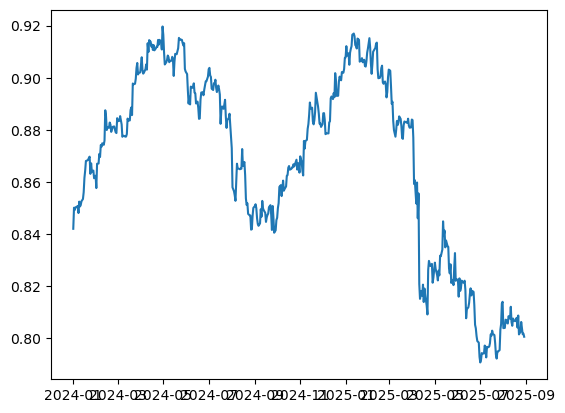

In [82]:
# plt.plot(df[['close','adjClose']].tail())
x = df['close']
print(x)


# plt.plot(df['close'])  # or 'Close' depending on what you want to chart
plt.plot(x)  # or 'Close' depending on what you want to chart
plt.show()
# plt.plot(ulvr['Close'])  # or 'Close' depending on what you want to chart